# Matrices, Part 1

Notebook ini merangkum Chapter 5 dari *Practical Linear Algebra for Data Science*. Chapter ini mulai masuk ke konsep matrix sebagai perluasan dari vector. Pembahasannya mencakup cara membuat dan memvisualisasikan matrix, special matrices, operasi element-wise, matrix shifting, standard matrix multiplication, matrix-vector multiplication, transpose, LIVE EVIL rule, dan symmetric matrices.

## Tujuan Pembelajaran

- Memahami matrix sebagai susunan angka dalam baris dan kolom.
- Membuat, mengindeks, dan slicing matrix menggunakan NumPy.
- Mengenali beberapa special matrices seperti square, diagonal, triangular, identity, dan zeros matrix.
- Melakukan matrix addition, scalar multiplication, dan Hadamard multiplication.
- Memahami konsep shifting matrix.
- Memahami aturan validitas standard matrix multiplication.
- Memahami matrix-vector multiplication sebagai linear weighted combination dan geometric transformation.
- Memahami transpose, LIVE EVIL rule, dan symmetric matrix.

## Ringkasan Chapter

Chapter ini memperkenalkan matrix sebagai objek matematika yang sangat fleksibel. Matrix dapat dipahami sebagai kumpulan column vectors, kumpulan row vectors, atau susunan elemen individual. Dalam data science, matrix sering muncul sebagai data table, dengan baris sebagai observasi dan kolom sebagai fitur.

Chapter ini juga membahas beberapa jenis matrix khusus, seperti random matrix, square matrix, diagonal matrix, triangular matrix, identity matrix, dan zeros matrix. Jenis-jenis matrix ini penting karena sering muncul dalam operasi linear algebra dan memiliki properti tertentu.

Bagian operasi matrix membedakan operasi yang bersifat element-wise, seperti addition, scalar multiplication, dan Hadamard multiplication, dengan standard matrix multiplication yang bekerja melalui dot product antara baris dan kolom. Chapter ini juga memperkenalkan matrix shifting, transpose, LIVE EVIL rule, serta symmetric matrices.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Creating and Visualizing Matrices | Matrix dapat dibuat, divisualisasikan, diindeks, dan di-slice di NumPy. |
| Special Matrices | Beberapa matrix memiliki bentuk dan properti khusus. |
| Matrix Addition and Multiplication | Addition, scalar multiplication, dan Hadamard multiplication bekerja element-wise. |
| Shifting a Matrix | Shifting dilakukan dengan menambahkan scalar pada diagonal melalui identity matrix. |
| Standard Matrix Multiplication | Matrix multiplication adalah kumpulan dot product antara row dan column. |
| Matrix-Vector Multiplication | Matrix dapat mentransformasi vector atau membentuk linear weighted combination. |
| Transpose and LIVE EVIL | Transpose menukar rows dan columns, serta membalik urutan perkalian matrix. |
| Symmetric Matrices | Matrix symmetric memenuhi $A^T=A$. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2024)

## Creating and Visualizing Matrices in NumPy

Matrix adalah susunan angka dalam format baris dan kolom. Ukuran matrix ditulis dengan konvensi:

$$
\text{rows} \times \text{columns}
$$

Contohnya, matrix dengan 3 baris dan 5 kolom disebut matrix $3 \times 5$.

Dalam Python, matrix dapat dibuat menggunakan `np.array()`, `np.arange()`, atau fungsi NumPy lain. Untuk matrix besar, visualisasi sebagai image sering lebih mudah daripada mencetak seluruh elemen.

In [2]:
A = np.array([
    [1, 3, 5, 7, 9],
    [0, 2, 4, 6, 8],
    [1, 4, 7, 8, 9]
])

print(A)
print("Shape:", A.shape)

[[1 3 5 7 9]
 [0 2 4 6 8]
 [1 4 7 8 9]]
Shape: (3, 5)


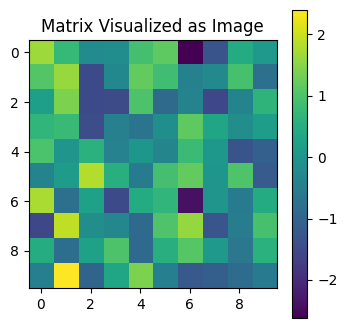

In [3]:
M = np.random.randn(10, 10)

plt.figure(figsize=(4, 4))
plt.imshow(M)
plt.colorbar()
plt.title("Matrix Visualized as Image")
plt.show()

## Indexing dan Slicing Matrix

Elemen matrix dapat diakses menggunakan indeks baris dan kolom. Perbedaan penting:

- Matematika menggunakan **1-based indexing**.
- Python menggunakan **0-based indexing**.

Jadi elemen $a_{3,4}$ dalam notasi matematika diakses di Python sebagai:

```python
A[2, 3]
```

Slicing digunakan untuk mengambil sebagian rows dan columns dari matrix.

In [4]:
A = np.arange(60).reshape(6, 10)

sub = A[1:4:1, 0:5:1]

print("Original matrix:")
print(A)

print("\nSubmatrix:")
print(sub)

Original matrix:
[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]]

Submatrix:
[[10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


## Special Matrices

Chapter ini menjelaskan beberapa kategori matrix yang sering muncul dalam linear algebra.

| Jenis Matrix | Ringkasan |
|---|---|
| Random numbers matrix | Matrix berisi angka acak dari distribusi tertentu. |
| Square matrix | Jumlah rows dan columns sama. |
| Rectangular matrix | Jumlah rows dan columns berbeda. |
| Diagonal matrix | Elemen nonzero hanya mungkin muncul pada diagonal utama. |
| Triangular matrix | Elemen nol berada di atas atau di bawah diagonal utama. |
| Identity matrix | Matrix diagonal dengan nilai 1 pada diagonal utama. |
| Zeros matrix | Matrix yang seluruh elemennya nol. |

In [5]:
A_random = np.random.randn(4, 6)
A_square = np.random.randn(4, 4)
A_diag = np.diag([2, 5, 1, 2])
A_upper = np.triu(np.random.randint(0, 10, (4, 4)))
A_lower = np.tril(np.random.randint(0, 10, (4, 4)))
A_identity = np.eye(4)
A_zeros = np.zeros((3, 5))

print("Random matrix shape:", A_random.shape)
print("Square matrix shape:", A_square.shape)
print("\nDiagonal matrix:")
print(A_diag)
print("\nIdentity matrix:")
print(A_identity)

Random matrix shape: (4, 6)
Square matrix shape: (4, 4)

Diagonal matrix:
[[2 0 0 0]
 [0 5 0 0]
 [0 0 1 0]
 [0 0 0 2]]

Identity matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## Visualisasi Special Matrices

Visualisasi matrix sebagai image membantu melihat pola struktur matrix, terutama untuk diagonal, triangular, identity, dan zeros matrix.

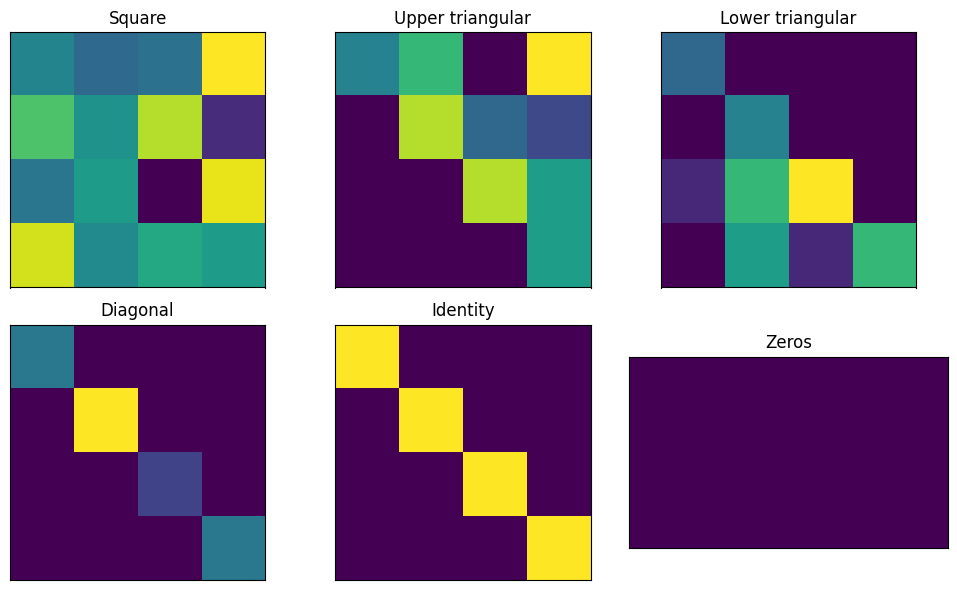

In [6]:
matrices = [
    ("Square", A_square),
    ("Upper triangular", A_upper),
    ("Lower triangular", A_lower),
    ("Diagonal", A_diag),
    ("Identity", A_identity),
    ("Zeros", A_zeros)
]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, (title, mat) in zip(axes.ravel(), matrices):
    ax.imshow(mat)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Matrix Addition and Subtraction

Matrix addition dilakukan dengan menjumlahkan elemen yang posisinya sama. Operasi ini hanya valid jika kedua matrix memiliki ukuran yang sama.

### Rumus Matrix Addition

$$
C = A + B
$$

dengan elemen:

$$
c_{i,j} = a_{i,j} + b_{i,j}
$$

Keterangan:

- $A$ dan $B$ = matrix dengan ukuran yang sama
- $C$ = matrix hasil penjumlahan
- $a_{i,j}$ dan $b_{i,j}$ = elemen pada posisi baris ke-$i$ dan kolom ke-$j$

In [7]:
A = np.array([
    [2, 3, 4],
    [1, 2, 4]
])

B = np.array([
    [0, 3, 1],
    [-1, -4, 2]
])

A + B

array([[ 2,  6,  5],
       [ 0, -2,  6]])

## Shifting a Matrix

Secara formal, scalar tidak ditambahkan ke seluruh elemen matrix dalam linear algebra. Namun, ada operasi yang disebut **shifting a matrix**, yaitu menambahkan scalar ke diagonal matrix.

### Rumus Matrix Shifting

$$
A + \lambda I
$$

Keterangan:

- $A$ = square matrix
- $\lambda$ = scalar
- $I$ = identity matrix
- Hanya elemen diagonal yang berubah

Shifting penting karena digunakan dalam pencarian eigenvalues dan regularization pada model statistik.

In [8]:
A = np.array([
    [4, 5, 1],
    [0, 1, 11],
    [4, 9, 7]
])

s = 6

print("A + s, bukan shifting:")
print(A + s)

print("\nA + sI, shifting:")
print(A + s*np.eye(len(A)))

A + s, bukan shifting:
[[10 11  7]
 [ 6  7 17]
 [10 15 13]]

A + sI, shifting:
[[10.  5.  1.]
 [ 0.  7. 11.]
 [ 4.  9. 13.]]


## Scalar and Hadamard Multiplication

Scalar-matrix multiplication berarti mengalikan setiap elemen matrix dengan scalar.

### Rumus Scalar-Matrix Multiplication

$$
\gamma
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
=
\begin{bmatrix}
\gamma a & \gamma b \\
\gamma c & \gamma d
\end{bmatrix}
$$

Hadamard multiplication adalah perkalian element-wise antara dua matrix yang ukurannya sama.

### Rumus Hadamard Multiplication

$$
A \odot B
$$

dengan elemen:

$$
c_{i,j} = a_{i,j}b_{i,j}
$$

In [9]:
A = np.random.randn(3, 4)
B = np.random.randn(3, 4)

print("Scalar multiplication:")
print(2 * A)

print("\nHadamard multiplication:")
print(A * B)

print("\nUsing np.multiply:")
print(np.multiply(A, B))

Scalar multiplication:
[[ 0.63872441  4.94457644 -2.12423715 -1.89133402]
 [-0.60690679  0.5042083  -0.28178642 -0.65674647]
 [ 2.79615231 -0.73314877 -4.5640684  -2.0157858 ]]

Hadamard multiplication:
[[-0.36364517  2.61901326  0.43439021 -1.32966593]
 [-0.16750305 -0.16500529 -0.13334167 -0.0290148 ]
 [ 3.69294447  0.44583343  4.05731033  0.58594423]]

Using np.multiply:
[[-0.36364517  2.61901326  0.43439021 -1.32966593]
 [-0.16750305 -0.16500529 -0.13334167 -0.0290148 ]
 [ 3.69294447  0.44583343  4.05731033  0.58594423]]


## Standard Matrix Multiplication

Standard matrix multiplication berbeda dari Hadamard multiplication. Operasi ini tidak dilakukan element-wise, tetapi menggunakan dot product antara rows dari matrix kiri dan columns dari matrix kanan.

Matrix multiplication valid hanya jika inner dimensions cocok.

Jika:

$$
A \in \mathbb{R}^{M \times N}
$$

dan

$$
B \in \mathbb{R}^{N \times K}
$$

maka:

$$
AB \in \mathbb{R}^{M \times K}
$$

Keterangan:

- $N$ pada matrix kiri dan kanan harus sama.
- Ukuran hasil ditentukan oleh outer dimensions, yaitu $M \times K$.

## Rumus Matrix Multiplication

Contoh matrix multiplication:

$$
\begin{bmatrix}
2 & 3 \\
4 & 5
\end{bmatrix}
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
=
\begin{bmatrix}
2a+3c & 2b+3d \\
4a+5c & 4b+5d
\end{bmatrix}
$$

Setiap elemen hasil adalah dot product antara row dari matrix kiri dan column dari matrix kanan.

In [10]:
A = np.array([
    [2, 3],
    [4, 5]
])

B = np.array([
    [1, 2],
    [3, 4]
])

print("Hadamard multiplication:")
print(A * B)

print("\nStandard matrix multiplication:")
print(A @ B)

Hadamard multiplication:
[[ 2  6]
 [12 20]]

Standard matrix multiplication:
[[11 16]
 [19 28]]


## Matrix Multiplication Tidak Komutatif

Matrix multiplication umumnya tidak memenuhi sifat komutatif.

$$
AB \ne BA
$$

Bahkan, dalam beberapa kasus $AB$ valid tetapi $BA$ tidak valid. Jika keduanya valid, hasilnya tetap belum tentu sama.

In [11]:
A = np.random.randn(2, 3)
B = np.random.randn(3, 4)

print("A shape:", A.shape)
print("B shape:", B.shape)
print("A @ B shape:", (A @ B).shape)

try:
    print(B @ A)
except ValueError as e:
    print("B @ A invalid:", e)

A shape: (2, 3)
B shape: (3, 4)
A @ B shape: (2, 4)
B @ A invalid: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)


## Matrix-Vector Multiplication

Matrix-vector multiplication adalah matrix multiplication ketika salah satu matrix berupa vector. Hasilnya selalu vector.

Chapter ini menekankan dua interpretasi penting:

1. Matrix-vector multiplication sebagai linear weighted combination.
2. Matrix-vector multiplication sebagai geometric transformation.

Dalam data science, matrix-vector multiplication muncul pada regression, PCA, signal processing, dan computer graphics.

## Matrix-Vector Multiplication sebagai Linear Weighted Combination

Jika column vectors disusun menjadi sebuah matrix, dan weights disusun menjadi vector, maka matrix-vector multiplication menghasilkan linear weighted combination.

Secara konsep:

$$
As = s_1a_1 + s_2a_2 + \cdots + s_na_n
$$

Keterangan:

- $A$ = matrix yang kolomnya berisi vector
- $s$ = vector berisi weights
- $a_i$ = column vector ke-$i$
- $s_i$ = weight ke-$i$

In [12]:
A = np.array([
    [3, 1],
    [0, 2],
    [6, 5]
])

s = np.array([4, 3])

A @ s

array([15,  6, 39])

## Matrix-Vector Multiplication sebagai Geometric Transform

Matrix juga dapat menyimpan transformasi. Ketika matrix dikalikan dengan vector, vector dapat mengalami perubahan arah dan panjang, seperti rotasi dan scaling.

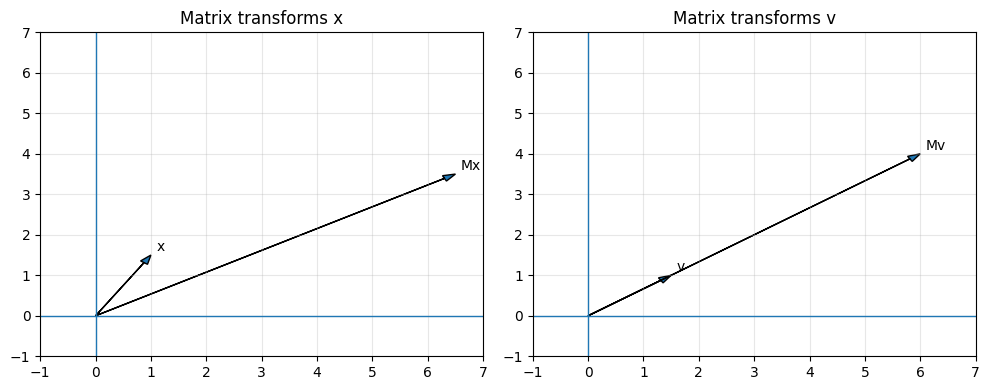

In [13]:
M = np.array([
    [2, 3],
    [2, 1]
])

x = np.array([[1, 1.5]]).T
Mx = M @ x

v = np.array([[1.5, 1]]).T
Mv = M @ v

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

def draw_vec(ax, vec, label):
    ax.arrow(0, 0, vec[0,0], vec[1,0], head_width=.15, length_includes_head=True)
    ax.text(vec[0,0]+.1, vec[1,0]+.1, label)

draw_vec(axes[0], x, "x")
draw_vec(axes[0], Mx, "Mx")
axes[0].set_title("Matrix transforms x")

draw_vec(axes[1], v, "v")
draw_vec(axes[1], Mv, "Mv")
axes[1].set_title("Matrix transforms v")

for ax in axes:
    ax.set_xlim(-1, 7)
    ax.set_ylim(-1, 7)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Matrix Operations: Transpose

Transpose menukar rows dan columns. Jika matrix $A$ memiliki ukuran $M \times N$, maka $A^T$ memiliki ukuran $N \times M$.

### Rumus Transpose

$$
a_{i,j}^{T} = a_{j,i}
$$

Keterangan:

- $a_{i,j}$ = elemen pada row ke-$i$ dan column ke-$j$
- $a_{j,i}$ = elemen setelah transpose
- Double transpose mengembalikan matrix awal:

$$
A^{TT} = A
$$

In [14]:
A = np.array([
    [3, 4, 5],
    [1, 2, 3]
])

print("A:")
print(A)

print("\nA.T:")
print(A.T)

print("\nnp.transpose(A):")
print(np.transpose(A))

A:
[[3 4 5]
 [1 2 3]]

A.T:
[[3 1]
 [4 2]
 [5 3]]

np.transpose(A):
[[3 1]
 [4 2]
 [5 3]]


## Dot Product dan Outer Product Notation

Transpose membantu menjelaskan notasi dot product dan outer product.

Untuk dua column vectors:

- Dot product ditulis sebagai $a^Tb$ dan menghasilkan scalar.
- Outer product ditulis sebagai $ab^T$ dan menghasilkan matrix.

Perbedaannya berasal dari aturan validitas matrix multiplication.

In [15]:
a = np.array([[1], [2], [3]])
b = np.array([[4], [5], [6]])

dot_product = a.T @ b
outer_product = a @ b.T

print("a.T @ b:")
print(dot_product)

print("\na @ b.T:")
print(outer_product)

a.T @ b:
[[32]]

a @ b.T:
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]


## LIVE EVIL Rule

LIVE EVIL adalah mnemonic untuk mengingat aturan transpose pada perkalian beberapa matrix. Aturannya: transpose dari hasil perkalian matrix sama dengan perkalian matrix yang masing-masing ditranspose, tetapi urutannya dibalik.

### Rumus LIVE EVIL

$$
(LIVE)^T = E^T V^T I^T L^T
$$

Secara umum:

$$
(AB)^T = B^TA^T
$$

Keterangan:

- Urutan matrix harus dibalik setelah transpose.
- Aturan ini berlaku untuk perkalian dua matrix atau lebih.

In [16]:
L = np.random.randn(2, 6)
I = np.random.randn(6, 3)
V = np.random.randn(3, 5)
E = np.random.randn(5, 2)

left = (L @ I @ V @ E).T
right = E.T @ V.T @ I.T @ L.T

print(np.allclose(left, right))

True


## Symmetric Matrices

Matrix symmetric adalah matrix yang sama dengan transpose-nya.

### Rumus Symmetric Matrix

$$
A^T = A
$$

Keterangan:

- Matrix harus square.
- Elemen pada row dan column yang bersesuaian harus sama.
- Matrix symmetric terlihat seperti tercermin terhadap diagonal utama.

Matrix nonsquare tidak bisa symmetric karena transpose-nya memiliki ukuran berbeda.

In [17]:
A = np.array([
    [1, 2, 3],
    [2, 5, 6],
    [3, 6, 9]
])

print("A:")
print(A)

print("\nA.T:")
print(A.T)

print("\nIs symmetric?", np.allclose(A, A.T))

A:
[[1 2 3]
 [2 5 6]
 [3 6 9]]

A.T:
[[1 2 3]
 [2 5 6]
 [3 6 9]]

Is symmetric? True


## Membuat Symmetric Matrix dari Matrix Umum

Chapter menjelaskan bahwa matrix umum dapat dibuat menjadi symmetric melalui perkalian dengan transpose-nya.

Jika $A$ adalah matrix apa pun, maka:

$$
A^TA
$$

dan

$$
AA^T
$$

keduanya square symmetric matrices.

Namun, jika $A$ nonsquare, ukuran $A^TA$ dan $AA^T$ berbeda.

In [18]:
A = np.random.randn(4, 3)

AtA = A.T @ A
AAt = A @ A.T

print("A shape:", A.shape)
print("A.T @ A shape:", AtA.shape)
print("A @ A.T shape:", AAt.shape)

print("\nIs A.T @ A symmetric?", np.allclose(AtA, AtA.T))
print("Is A @ A.T symmetric?", np.allclose(AAt, AAt.T))

A shape: (4, 3)
A.T @ A shape: (3, 3)
A @ A.T shape: (4, 4)

Is A.T @ A symmetric? True
Is A @ A.T symmetric? True


## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Matrix | Susunan angka dalam rows dan columns. |
| Shape | Ukuran matrix dalam format rows × columns. |
| Indexing | Mengakses elemen matrix berdasarkan posisi row dan column. |
| Slicing | Mengambil submatrix dari matrix utama. |
| Special matrices | Matrix dengan struktur tertentu seperti diagonal, identity, triangular, dan zeros. |
| Matrix addition | Penjumlahan element-wise antara matrix berukuran sama. |
| Shifting | Menambahkan scalar ke diagonal menggunakan $\lambda I$. |
| Hadamard multiplication | Perkalian element-wise antara dua matrix. |
| Matrix multiplication | Kumpulan dot product antara rows dan columns. |
| Matrix-vector multiplication | Matrix multiplication yang menghasilkan vector. |
| Transpose | Operasi menukar rows dan columns. |
| LIVE EVIL | Aturan transpose untuk perkalian matrix, dengan urutan dibalik. |
| Symmetric matrix | Matrix yang memenuhi $A^T=A$. |

## Kesimpulan Chapter

Chapter ini memperkenalkan matrix sebagai perluasan dari vector dan sebagai struktur utama dalam linear algebra. Matrix dapat dipahami sebagai data table, kumpulan row vectors, kumpulan column vectors, atau susunan elemen individual.

Operasi matrix terbagi menjadi operasi element-wise dan standard matrix multiplication. Addition, scalar multiplication, dan Hadamard multiplication bekerja element-wise, sedangkan standard matrix multiplication bekerja melalui dot product antara rows dan columns.

Chapter ini juga memperkenalkan beberapa konsep penting untuk chapter berikutnya, seperti matrix shifting, matrix-vector multiplication, transpose, LIVE EVIL rule, dan symmetric matrices. Pemahaman terhadap konsep-konsep ini menjadi dasar untuk mempelajari matrix spaces, inverse, rank, least squares, eigendecomposition, dan SVD.